# TA-Lib Indicator Tester (One-by-One)

Interactive notebook to load your OHLC CSV and test **each TA-Lib indicator** individually.

**Setup** (run once in terminal if needed):
```bash
pip install -e ".[dev]"
pip install jupyter ipywidgets
```

**How to use**
1. Run **Setup** and **Load data** cells.
2. Pick an indicator from the dropdown (or set `INDICATOR` manually).
3. Run **Test one indicator** to validate + plot.
4. Use **Previous / Next** buttons to step through all indicators one by one.

In [ ]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from indicator_testing.data_loader import describe_ohlc, load_ohlc
from indicator_testing.plotter import plot_indicator
from indicator_testing.registry import IndicatorRegistry
from indicator_testing.runner import run_indicator

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("Tip: pip install ipywidgets for dropdown + prev/next buttons")

print(f"Project root: {PROJECT_ROOT}")

## Configuration

Edit the paths and options below, then re-run this cell.

In [ ]:
CSV_PATH = PROJECT_ROOT / "questdb-query-1781940224994.csv" 

RESAMPLE = "daily" 
SYMBOL = None        

INDICATOR = "RSI"

PARAMS = {}  

In [3]:
resample_arg = None if RESAMPLE == "none" else RESAMPLE
df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)
info = describe_ohlc(df)

registry = IndicatorRegistry()
all_indicators = [i.name for i in registry.iter_ordered()]
groups = registry.groups()

print(f"Loaded {info['bars']} bars | {info['inferred_frequency']}")
print(f"Range: {info['start']} -> {info['end']}")
print(f"Close: {info['close_min']:.2f} - {info['close_max']:.2f} | Volume: {info['has_volume']}")
print(f"TA-Lib indicators available: {len(all_indicators)}")
print()
for gname, names in groups.items():
    print(f"  {gname}: {len(names)}")

df.tail(3)

Loaded 52 bars | daily
Range: 2026-04-01 00:00:00+00:00 -> 2026-06-19 00:00:00+00:00
Close: 22700.70 - 24580.60 | Volume: True
TA-Lib indicators available: 158

  Cycle Indicators: 5
  Math Operators: 11
  Math Transform: 15
  Momentum Indicators: 30
  Overlap Studies: 17
  Pattern Recognition: 61
  Price Transform: 4
  Statistic Functions: 9
  Volatility Indicators: 3
  Volume Indicators: 3


C:\Users\mohxm\AppData\Local\Temp\ipykernel_18940\4190215087.py:2: UserWarning: Dropping 16500 duplicate timestamp(s), keeping last occurrence.
  df = load_ohlc(CSV_PATH, resample=resample_arg, symbol=SYMBOL, warn_short=False)


,open,high,low,close,volume
date,,,,,
2026-06-17 00:00:00+00:00,24044.5,24108.20,23969.70,24081.95,350689158
2026-06-18 00:00:00+00:00,24073.8,24189.25,24036.95,24179.40,337400862
2026-06-19 00:00:00+00:00,23991.2,24047.20,23901.90,24042.70,442811653


## Pick an indicator

Use the dropdown and **Prev / Next** buttons, or set `INDICATOR = "MACD"` in the config cell.

In [9]:
current_index = all_indicators.index(INDICATOR.upper()) if INDICATOR.upper() in all_indicators else 0

if HAS_WIDGETS:
    indicator_dropdown = widgets.Dropdown(
        options=[(f"{n} ({registry.get(n).group})", n) for n in all_indicators],
        value=all_indicators[current_index],
        description="Indicator:",
        layout=widgets.Layout(width="500px"),
    )
    btn_prev = widgets.Button(description="<< Prev", button_style="info")
    btn_next = widgets.Button(description="Next >>", button_style="info")
    out_pick = widgets.Output()

    def _sync_index(change=None):
        global current_index
        current_index = all_indicators.index(indicator_dropdown.value)

    def _go_prev(_):
        global current_index
        current_index = (current_index - 1) % len(all_indicators)
        indicator_dropdown.value = all_indicators[current_index]

    def _go_next(_):
        global current_index
        current_index = (current_index + 1) % len(all_indicators)
        indicator_dropdown.value = all_indicators[current_index]

    indicator_dropdown.observe(_sync_index, names="value")
    btn_prev.on_click(_go_prev)
    btn_next.on_click(_go_next)

    display(widgets.HBox([btn_prev, indicator_dropdown, btn_next]))
else:
    print(f"Current INDICATOR = {INDICATOR}")
    print("Available (first 20):", all_indicators[:20])

## Test one indicator

Runs TA-Lib, validates output, shows a sample table, and plots a chart.

ROCP  |  Momentum Indicators
Status: success  |  Warmup bars: 10
Inputs: ['close']  |  Outputs: ['real']
Params: {'timeperiod': 10}
Validation: PASS
  [OK] length: All output lengths match input.
  [OK] post_warmup_data: At least one finite value after warmup.
  [OK] not_all_nan: Outputs contain data after warmup.


,close,real,_warmup
date,,,
2026-06-01 00:00:00+00:00,23379.20,-0.011841,False
2026-06-02 00:00:00+00:00,23523.30,-0.005124,False
2026-06-03 00:00:00+00:00,23396.95,-0.008864,False
2026-06-04 00:00:00+00:00,23438.00,-0.009557,False
2026-06-05 00:00:00+00:00,23368.85,-0.011829,False
2026-06-08 00:00:00+00:00,23103.70,-0.027166,False
2026-06-09 00:00:00+00:00,23257.75,-0.032938,False
2026-06-10 00:00:00+00:00,23216.10,-0.029985,False
2026-06-11 00:00:00+00:00,23186.55,-0.030727,False


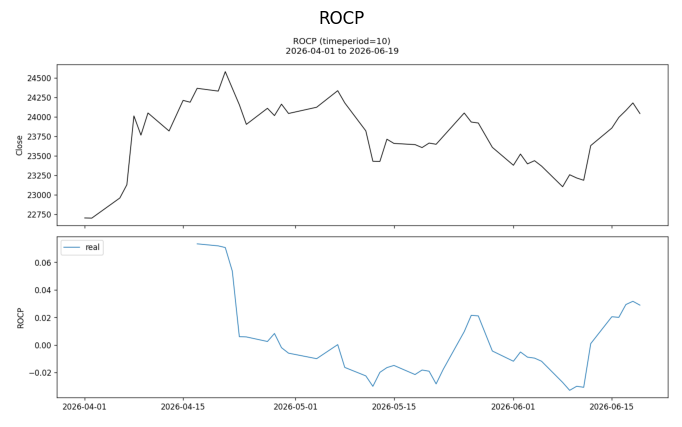

In [10]:
def get_selected_indicator():
    if HAS_WIDGETS:
        return indicator_dropdown.value
    return INDICATOR.upper()


def show_validation(result):
    info = registry.get(result.name)
    print(f"{'='*60}")
    print(f"{result.name}  |  {result.group}")
    print(f"Status: {result.status}  |  Warmup bars: {result.warmup_bars}")
    print(f"Inputs: {info.input_names}  |  Outputs: {info.output_names}")
    print(f"Params: {result.params_used}")
    if result.message and result.status != "success":
        print(f"Message: {result.message}")
    if result.validation:
        tag = "PASS" if result.validation.passed else "FAIL"
        print(f"Validation: {tag}")
        for c in result.validation.checks:
            mark = "OK" if c.passed else "X"
            print(f"  [{mark}] {c.name}: {c.message}")
    print(f"{'='*60}")


def result_to_frame(result, n_tail=15):
    if result.status != "success" or not result.outputs:
        return pd.DataFrame()
    out = pd.DataFrame({"close": df["close"]})
    for k, arr in result.outputs.items():
        out[k] = arr
    out.index = df.index
    warmup = result.warmup_bars or 0
    out["_warmup"] = [i < warmup for i in range(len(out))]
    return out.tail(n_tail)


def plot_inline(result):
    if result.status != "success" or not result.outputs:
        print("Nothing to plot.")
        return
    chart_path = PROJECT_ROOT / "outputs" / "charts" / "notebook_preview.png"
    chart_path.parent.mkdir(parents=True, exist_ok=True)
    plot_indicator(df, result, chart_path, show=False)
    img = plt.imread(chart_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(result.name)
    plt.show()


name = get_selected_indicator()
result = run_indicator(name, df, registry, params=PARAMS or None)
show_validation(result)
display(result_to_frame(result))
plot_inline(result)

## Browse all indicators (one by one)

Run this cell to step through **every** indicator sequentially.  
Set `MAX_TO_SHOW = 5` to limit how many are displayed per run, or `None` for all.

In [ ]:
MAX_TO_SHOW = None 
SHOW_PLOT_EACH = False  
rows = []
to_run = all_indicators[:MAX_TO_SHOW] if MAX_TO_SHOW else all_indicators

for i, name in enumerate(to_run, start=1):
    r = run_indicator(name, df, registry)
    valid = r.validation.passed if r.validation else None
    rows.append({
        "#": i,
        "indicator": r.name,
        "group": r.group,
        "status": r.status,
        "warmup": r.warmup_bars,
        "valid": valid,
        "message": r.message if r.status != "success" else "",
    })
    if SHOW_PLOT_EACH and r.status == "success":
        print(f"[{i}/{len(to_run)}] {name}")
        plot_inline(r)

summary = pd.DataFrame(rows)
print(f"Done: {len(summary)} indicators")
print(summary["status"].value_counts().to_string())
summary

Done: 158 indicators
status
success    158


,#,indicator,group,status,warmup,valid,message
0,1,HT_DCPERIOD,Cycle Indicators,success,32,True,
1,2,HT_DCPHASE,Cycle Indicators,success,52,False,
2,3,HT_PHASOR,Cycle Indicators,success,32,True,
3,4,HT_SINE,Cycle Indicators,success,52,False,
4,5,HT_TRENDMODE,Cycle Indicators,success,0,True,
...,...,...,...,...,...,...,...
153,154,NATR,Volatility Indicators,success,14,True,
154,155,TRANGE,Volatility Indicators,success,1,True,
155,156,AD,Volume Indicators,success,0,True,
156,157,ADOSC,Volume Indicators,success,9,True,


## Filter summary

Show only failures, skips, or a specific group from the batch run above.

In [ ]:
if "summary" in dir():
    display(summary[summary["status"] != "success"])
    print()
    display(summary.groupby("group")["status"].value_counts())
else:
    print("Run the 'Browse all indicators' cell first.")

,#,indicator,group,status,warmup,valid,message


group                  status 
Cycle Indicators       success     5
Math Operators         success    11
Math Transform         success    15
Momentum Indicators    success    30
Overlap Studies        success    17
Pattern Recognition    success    61
Price Transform        success     4
Statistic Functions    success     9
Volatility Indicators  success     3
Volume Indicators      success     3
Name: count, dtype: int64

## Quick reference — indicators by group

In [8]:
for gname, names in groups.items():
    print(f"\n=== {gname} ({len(names)}) ===")
    for n in names:
        info = registry.get(n)
        vol = " [vol]" if info.requires_volume else ""
        print(f"  {n:<18} in={info.input_names} out={info.output_names}{vol}")


=== Cycle Indicators (5) ===
  HT_DCPERIOD        in=['close'] out=['real']
  HT_DCPHASE         in=['close'] out=['real']
  HT_PHASOR          in=['close'] out=['inphase', 'quadrature']
  HT_SINE            in=['close'] out=['sine', 'leadsine']
  HT_TRENDMODE       in=['close'] out=['integer']

=== Math Operators (11) ===
  ADD                in=[] out=['real']
  DIV                in=[] out=['real']
  MAX                in=['close'] out=['real']
  MAXINDEX           in=['close'] out=['integer']
  MIN                in=['close'] out=['real']
  MININDEX           in=['close'] out=['integer']
  MINMAX             in=['close'] out=['min', 'max']
  MINMAXINDEX        in=['close'] out=['minidx', 'maxidx']
  MULT               in=[] out=['real']
  SUB                in=[] out=['real']
  SUM                in=['close'] out=['real']

=== Math Transform (15) ===
  ACOS               in=['close'] out=['real']
  ASIN               in=['close'] out=['real']
  ATAN               in=['close'] out=